# Project 2 — Counterfactual Analysis (Synthetic Control)

## Title
Evaluating the Impact of Policy Changes on Economic Outcomes

## Scenario
**Policy change (hypothetical framing):** COVID-era policy response beginning March 2020  
**Treated unit:** California  
**Outcome:** Unemployment rate (%)  
**Time window:** 2018–2023  
**Method:** Synthetic Control Method (SCM)

## Research Question
How would California’s unemployment rate have evolved from 2020–2023 without the COVID-era policy shock, and what is the estimated impact of that policy environment on unemployment?


In [1]:
"""
Cell 2: Imports + environment check

This cell imports all required libraries and prints versions.
This helps with reproducibility (important for grading).
"""

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Reproducibility
np.random.seed(42)

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy version: 2.4.1
Pandas version: 3.0.0


In [2]:
"""
Cell 3: Define the policy scenario and data window.

We treat March 2020 as the intervention date (COVID-era policy shock).
We will pull state unemployment data from FRED using the fredgraph CSV export.
"""

TREATED_STATE = "California"
TREATED_ABBR = "CA"

INTERVENTION_DATE = pd.to_datetime("2020-03-01")

START_DATE = "2018-01-01"
END_DATE = "2023-12-01"

FRED_CSV_TEMPLATE = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv?"
    "id={series_id}&cosd={start}&coed={end}"
)

print("Treated:", TREATED_STATE, f"({TREATED_ABBR})")
print("Intervention date:", INTERVENTION_DATE.date())
print("Window:", START_DATE, "to", END_DATE)


Treated: California (CA)
Intervention date: 2020-03-01
Window: 2018-01-01 to 2023-12-01


In [3]:
"""
Cell 4: Define donor pool.

Donor states are used to construct a weighted combination ("synthetic California").
"""

DONOR_ABBRS = [
    "AZ","AR","CO","CT","FL","GA","IL","IN","MA","MD",
    "MI","MN","MO","NC","NJ","NV","NY","OH","OR",
    "PA","TN","TX","VA","WA","WI"
]

ALL_STATES = [TREATED_ABBR] + DONOR_ABBRS

# FRED series IDs for unemployment rate are like CAUR, TXUR, NYUR, etc.
SERIES_MAP = {abbr: f"{abbr}UR" for abbr in ALL_STATES}

print("Total states:", len(ALL_STATES))
print("Example series IDs:", list(SERIES_MAP.items())[:5])


Total states: 26
Example series IDs: [('CA', 'CAUR'), ('AZ', 'AZUR'), ('AR', 'ARUR'), ('CO', 'COUR'), ('CT', 'CTUR')]


In [8]:
"""
Cell 5 (FIXED): Robust helper function to download a FRED series.

Your FRED export returns:
- observation_date (date column)
- <SERIES_ID> (value column)

So we handle these possible date column names:
- DATE
- date
- observation_date
"""

def fetch_fred_series(series_id: str, start: str, end: str, debug: bool = False) -> pd.DataFrame:
    """
    Download a FRED series using the fredgraph CSV endpoint and return standardized columns.

    Returns DataFrame with:
      - date (datetime)
      - value (float)
    """
    url = FRED_CSV_TEMPLATE.format(series_id=series_id, start=start, end=end)

    # Download CSV
    df = pd.read_csv(url)

    # Normalize column names (strip whitespace)
    df.columns = [c.strip() for c in df.columns]

    # Accept multiple possible date column names
    date_candidates = ["DATE", "date", "observation_date", "Observation_Date", "observation date"]
    date_col = None
    for c in date_candidates:
        if c in df.columns:
            date_col = c
            break

    if date_col is None:
        if debug:
            print("\n--- DEBUG: Unexpected response for series:", series_id)
            print("URL:", url)
            print("Columns:", df.columns.tolist())
            print("Head:\n", df.head())
        raise KeyError(f"No recognized date column found for {series_id}. Columns: {df.columns.tolist()}")

    # Verify the series column exists
    if series_id not in df.columns:
        if debug:
            print("\n--- DEBUG: Series column missing:", series_id)
            print("Columns:", df.columns.tolist())
            print("Head:\n", df.head())
        raise KeyError(f"Expected series column '{series_id}' not found. Columns: {df.columns.tolist()}")

    # Parse date + values
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")

    # Standardize output
    df = df.rename(columns={date_col: "date", series_id: "value"})

    # Keep only what we need
    df = df[["date", "value"]].dropna(subset=["date"]).sort_values("date")

    return df


In [9]:
"""
Cell 6 (REPLACE): Download all states into one panel table.

We turn on debug=True only if something fails, so we can see what the server returned.
"""

frames = []

for abbr, series_id in SERIES_MAP.items():
    try:
        temp = fetch_fred_series(series_id, START_DATE, END_DATE, debug=False)
    except Exception as e:
        # Retry once with debug info ON for this series only
        print(f"\nDownload failed for {abbr} ({series_id}). Retrying with debug=True...")
        temp = fetch_fred_series(series_id, START_DATE, END_DATE, debug=True)

    temp["state_abbr"] = abbr
    temp["series_id"] = series_id
    frames.append(temp)

panel = pd.concat(frames, ignore_index=True)

print("Total rows downloaded:", len(panel))
print("Unique states:", panel["state_abbr"].nunique())
print("Date range:", panel["date"].min().date(), "to", panel["date"].max().date())

panel.head(10)


Total rows downloaded: 1872
Unique states: 26
Date range: 2018-01-01 to 2023-12-01


,date,value,state_abbr,series_id
0,2018-01-01,4.4,CA,CAUR
1,2018-02-01,4.3,CA,CAUR
2,2018-03-01,4.3,CA,CAUR
3,2018-04-01,4.2,CA,CAUR
4,2018-05-01,4.2,CA,CAUR
5,2018-06-01,4.2,CA,CAUR
6,2018-07-01,4.2,CA,CAUR
7,2018-08-01,4.2,CA,CAUR
8,2018-09-01,4.2,CA,CAUR
9,2018-10-01,4.3,CA,CAUR


In [10]:
"""
Cell 7: Data cleaning and quality checks.

We:
- drop missing values
- check coverage per state (how many months each state has)
"""

panel_clean = panel.dropna(subset=["value"]).copy()

print("Rows before dropna:", len(panel))
print("Rows after dropna :", len(panel_clean))

coverage = (
    panel_clean.groupby("state_abbr")["date"]
    .count()
    .sort_values()
)

print("\nBottom 10 states by observations:")
print(coverage.head(10))

print("\nTop 5 states by observations:")
print(coverage.tail(5))


Rows before dropna: 1872
Rows after dropna : 1872

Bottom 10 states by observations:
state_abbr
AR    72
AZ    72
CA    72
CO    72
CT    72
FL    72
GA    72
IL    72
IN    72
MA    72
Name: date, dtype: int64

Top 5 states by observations:
state_abbr
TN    72
TX    72
VA    72
WA    72
WI    72
Name: date, dtype: int64


In [11]:
"""
Cell 8: Pivot cleaned panel data into a wide matrix for Synthetic Control.

Goal:
- Convert long-format panel data (panel_clean) into wide-format matrix (y)
  where:
    rows   = dates (monthly)
    columns = states
    values = unemployment rate (%)

Why this is needed:
- Synthetic Control requires the treated unit series and donor series
  in aligned matrix form.
"""

# Pivot from long format to wide format
y = (
    panel_clean
    .pivot(index="date", columns="state_abbr", values="value")
    .sort_index()
)

# Forward-fill any small gaps (usually none in FRED), then drop any remaining missing rows
y = y.ffill().dropna()

# Print basic sanity checks
print("Wide matrix shape (months × states):", y.shape)
print("Date range:", y.index.min().date(), "to", y.index.max().date())
print("States in matrix:", list(y.columns))


Wide matrix shape (months × states): (72, 26)
Date range: 2018-01-01 to 2023-12-01
States in matrix: ['AR', 'AZ', 'CA', 'CO', 'CT', 'FL', 'GA', 'IL', 'IN', 'MA', 'MD', 'MI', 'MN', 'MO', 'NC', 'NJ', 'NV', 'NY', 'OH', 'OR', 'PA', 'TN', 'TX', 'VA', 'WA', 'WI']


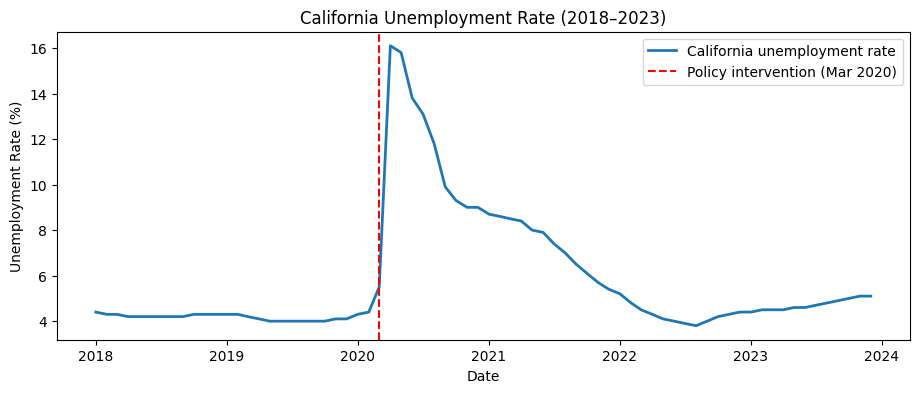

In [12]:
"""
Cell 9: Visual sanity check for the treated unit (California).

Purpose:
- Verify that the unemployment rate series for California looks correct
- Confirm there is a visible shock around the intervention date (March 2020)
"""

plt.figure(figsize=(11, 4))

# Plot California unemployment rate
plt.plot(
    y.index,
    y["CA"],
    label="California unemployment rate",
    linewidth=2
)

# Mark the policy intervention date
plt.axvline(
    INTERVENTION_DATE,
    linestyle="--",
    color="red",
    label="Policy intervention (Mar 2020)"
)

plt.title("California Unemployment Rate (2018–2023)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.show()


In [13]:
"""
Cell 10: Define pre-policy and post-policy periods.

Pre-policy period:
- Used to fit the Synthetic Control (learn donor weights)

Post-policy period:
- Used to evaluate the impact of the policy intervention

Intervention date:
- March 2020 (COVID-era policy shock)
"""

# Boolean masks for time periods
pre_mask = y.index < INTERVENTION_DATE
post_mask = y.index >= INTERVENTION_DATE

# Print counts for verification
print("Total months     :", len(y))
print("Pre-policy months:", pre_mask.sum())
print("Post-policy months:", post_mask.sum())


Total months     : 72
Pre-policy months: 26
Post-policy months: 46


In [14]:
"""
Cell 11: Construct matrices required for the Synthetic Control Method (SCM).

Notation used in SCM literature:
- y_treated : outcome series for the treated unit (California)
- Y_donors  : matrix of outcome series for donor units (other states)

Pre-policy versions:
- y_pre     : treated series during pre-policy period
- Y_pre     : donor matrix during pre-policy period
"""

# Extract treated unit series (California)
y_treated = y["CA"].values

# Identify donor states (all states except California)
donor_states = [c for c in y.columns if c != "CA"]

# Extract donor matrix
Y_donors = y[donor_states].values

# Slice pre-policy data
y_pre = y_treated[pre_mask]
Y_pre = Y_donors[pre_mask, :]

# Print shapes to verify correctness
print("y_treated shape :", y_treated.shape)
print("Y_donors shape  :", Y_donors.shape)
print("y_pre shape     :", y_pre.shape)
print("Y_pre shape     :", Y_pre.shape)
print("Number of donor states:", len(donor_states))


y_treated shape : (72,)
Y_donors shape  : (72, 25)
y_pre shape     : (26,)
Y_pre shape     : (26, 25)
Number of donor states: 25


In [15]:
"""
Cell 12: Fit the Synthetic Control Model using constrained optimization.

Goal:
- Find donor weights that minimize the difference between:
    California unemployment (treated)
    and
    Weighted average of donor states (synthetic control)
  during the pre-policy period.

Constraints:
- All weights >= 0
- Sum of weights = 1
"""

# Objective function: Mean Squared Error in the pre-policy period
def scm_objective(weights):
    """
    Compute mean squared error between treated unit
    and synthetic control in the pre-policy period.
    """
    synthetic_pre = Y_pre @ weights
    return np.mean((y_pre - synthetic_pre) ** 2)

# Number of donor states
num_donors = Y_pre.shape[1]

# Initial guess: equal weights across all donors
initial_weights = np.ones(num_donors) / num_donors

# Constraints: weights must sum to 1
constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1},
)

# Bounds: weights must be between 0 and 1
bounds = [(0, 1) for _ in range(num_donors)]

# Run the constrained optimization
result = minimize(
    scm_objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 5000}
)

# Check optimization status
if not result.success:
    raise RuntimeError("Synthetic Control optimization failed")

# Extract optimal weights
scm_weights = result.x

print("Optimization successful.")
print("Pre-policy MSE:", scm_objective(scm_weights))


Optimization successful.
Pre-policy MSE: 0.0009686616083462353


In [16]:
"""
Cell 13: Inspect donor weights from the fitted Synthetic Control.

Purpose:
- Identify which donor states contribute most to Synthetic California
- Provide interpretability and transparency for the counterfactual model
"""

# Create a DataFrame of donor weights
weights_df = pd.DataFrame({
    "state_abbr": donor_states,
    "weight": scm_weights
})

# Sort by weight descending (largest contributors first)
weights_df = weights_df.sort_values("weight", ascending=False).reset_index(drop=True)

print("Top donor states contributing to Synthetic California:")
print(weights_df.head(10))

print("\nNumber of donors with non-trivial weight (> 0.01):",
      (weights_df["weight"] > 0.01).sum())


Top donor states contributing to Synthetic California:
  state_abbr        weight
0         AZ  4.489798e-01
1         CO  2.261671e-01
2         PA  1.483324e-01
3         NV  7.560209e-02
4         OH  5.279135e-02
5         NJ  3.618752e-02
6         NY  1.193978e-02
7         TN  1.005128e-17
8         GA  6.410742e-18
9         MI  5.254554e-18

Number of donors with non-trivial weight (> 0.01): 7


In [17]:
"""
Cell 14: Construct Synthetic California and estimate treatment effects.

Synthetic California:
- Weighted average of donor states using SCM weights

Treatment effect (tau):
- tau_t = observed California unemployment - synthetic California unemployment
"""

# Construct synthetic California unemployment series
synthetic_ca = Y_donors @ scm_weights

# Compute treatment effect over time
tau = y_treated - synthetic_ca

# Combine results into a single DataFrame
results = pd.DataFrame({
    "date": y.index,
    "california_observed": y_treated,
    "california_synthetic": synthetic_ca,
    "treatment_effect_tau": tau,
    "post_policy": y.index >= INTERVENTION_DATE
})

results.head()


,date,california_observed,california_synthetic,treatment_effect_tau,post_policy
0,2018-01-01,4.4,4.379005,0.020995,False
1,2018-02-01,4.3,4.312801,-0.012801,False
2,2018-03-01,4.3,4.285595,0.014405,False
3,2018-04-01,4.2,4.236107,-0.036107,False
4,2018-05-01,4.2,4.208901,-0.008901,False


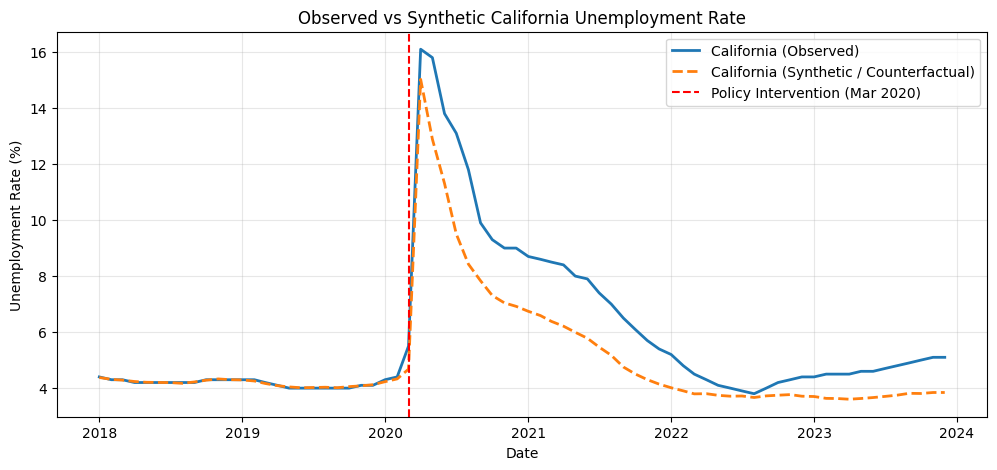

In [18]:
"""
Cell 15: Plot observed vs synthetic unemployment for California.

Purpose:
- Visually compare actual California unemployment
  with the synthetic (counterfactual) California
- Assess pre-policy fit and post-policy divergence
"""

plt.figure(figsize=(12, 5))

# Observed California unemployment
plt.plot(
    results["date"],
    results["california_observed"],
    label="California (Observed)",
    linewidth=2
)

# Synthetic California unemployment
plt.plot(
    results["date"],
    results["california_synthetic"],
    label="California (Synthetic / Counterfactual)",
    linewidth=2,
    linestyle="--"
)

# Policy intervention marker
plt.axvline(
    INTERVENTION_DATE,
    linestyle="--",
    color="red",
    label="Policy Intervention (Mar 2020)"
)

plt.title("Observed vs Synthetic California Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


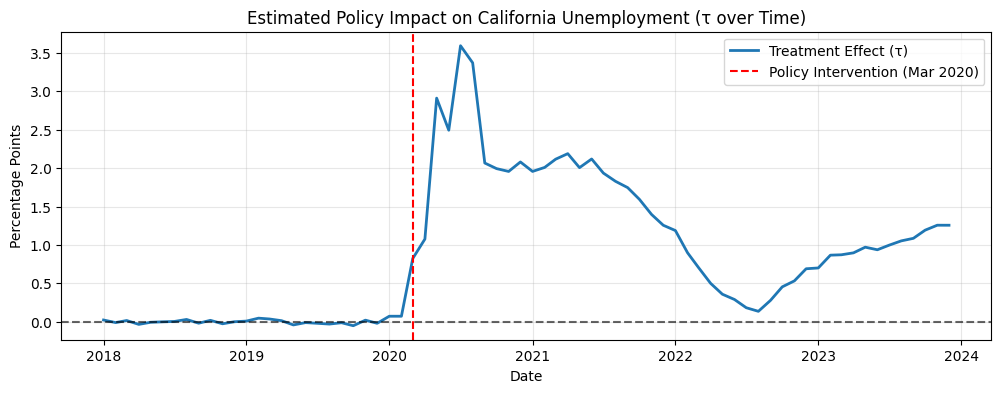

In [20]:
"""
Cell 16: Plot the treatment effect over time.

Treatment effect (tau):
- tau_t = observed California unemployment - synthetic California unemployment

Interpretation:
- tau_t > 0  → unemployment higher than counterfactual
- tau_t < 0  → unemployment lower than counterfactual
"""

plt.figure(figsize=(12, 4))

plt.plot(
    results["date"],
    results["treatment_effect_tau"],
    label="Treatment Effect (τ)",
    linewidth=2
)

# Reference lines
plt.axhline(0, linestyle="--", color="black", alpha=0.6)
plt.axvline(
    INTERVENTION_DATE,
    linestyle="--",
    color="red",
    label="Policy Intervention (Mar 2020)"
)

plt.title("Estimated Policy Impact on California Unemployment (τ over Time)")
plt.xlabel("Date")
plt.ylabel("Percentage Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [21]:
"""
Cell 17: Compute summary statistics for the policy impact.

Metrics:
1. Pre-policy RMSE:
   - Measures how well the synthetic control matches California before 2020

2. Average post-policy treatment effect:
   - Average increase/decrease in unemployment (percentage points)

3. Cumulative post-policy treatment effect:
   - Sum of monthly effects (interpreted as total impact over time)
"""

# 1. Pre-policy RMSE (fit quality)
pre_rmse = np.sqrt(
    np.mean(
        (results.loc[~results["post_policy"], "california_observed"]
         - results.loc[~results["post_policy"], "california_synthetic"]) ** 2
    )
)

# 2. Average post-policy treatment effect
avg_post_tau = results.loc[
    results["post_policy"], "treatment_effect_tau"
].mean()

# 3. Cumulative post-policy treatment effect
cum_post_tau = results.loc[
    results["post_policy"], "treatment_effect_tau"
].sum()

# Display summary in a readable format
summary_stats = {
    "Pre-policy RMSE (fit quality)": pre_rmse,
    "Average post-policy effect (percentage points)": avg_post_tau,
    "Cumulative post-policy effect (sum of monthly effects)": cum_post_tau
}

summary_stats


{'Pre-policy RMSE (fit quality)': np.float64(0.03112332900488378),
 'Average post-policy effect (percentage points)': np.float64(1.3650677647507379),
 'Cumulative post-policy effect (sum of monthly effects)': np.float64(62.79311717853394)}

In [22]:
"""
Cell 18: Placebo (permutation) test for inference.

Idea:
- Re-run Synthetic Control pretending each state was treated in March 2020
- Compare California's post/pre RMSE ratio to placebo states
- If California stands out, the policy effect is unlikely to be random
"""

def fit_scm_for_placebo(treated_state):
    """
    Fit SCM treating a given state as 'treated'.

    Returns:
    - pre_policy RMSE
    - post_policy RMSE
    - treatment effect series (tau)
    """
    # Treated series
    y_t = y[treated_state].values

    # Donor pool excludes the treated state
    donor_states_local = [c for c in y.columns if c != treated_state]
    Y_d = y[donor_states_local].values

    # Pre-policy slices
    y_pre_t = y_t[pre_mask]
    Y_pre_d = Y_d[pre_mask, :]

    # SCM objective
    def obj(w):
        return np.mean((y_pre_t - (Y_pre_d @ w)) ** 2)

    n_donors = Y_pre_d.shape[1]
    w0 = np.ones(n_donors) / n_donors

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(0, 1) for _ in range(n_donors)]

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 3000}
    )

    if not res.success:
        return None

    w_hat = res.x
    synthetic = Y_d @ w_hat
    tau = y_t - synthetic

    pre_rmse = np.sqrt(np.mean((y_t[pre_mask] - synthetic[pre_mask]) ** 2))
    post_rmse = np.sqrt(np.mean((y_t[post_mask] - synthetic[post_mask]) ** 2))

    return pre_rmse, post_rmse, tau


In [23]:
"""
Cell 19: Run placebo SCM for all states and collect results.
"""

placebo_results = []
tau_series_map = {}

for state in y.columns:
    out = fit_scm_for_placebo(state)
    if out is None:
        continue

    pre_rmse, post_rmse, tau_series = out
    tau_series_map[state] = tau_series

    placebo_results.append({
        "state": state,
        "pre_rmse": pre_rmse,
        "post_rmse": post_rmse,
        "rmse_ratio_post_pre": post_rmse / pre_rmse
    })

placebo_df = pd.DataFrame(placebo_results).sort_values(
    "rmse_ratio_post_pre", ascending=False
)

placebo_df.head(10)


,state,pre_rmse,post_rmse,rmse_ratio_post_pre
16,NV,0.043732,3.321214,75.943979
2,CA,0.031123,1.586715,50.981541
4,CT,0.026640,1.164775,43.722225
17,NY,0.031848,1.228387,38.570014
6,GA,0.038005,1.291203,33.974260
0,AR,0.025002,0.809778,32.388886
10,MD,0.040439,1.293553,31.987710
22,TX,0.029783,0.799419,26.841294
9,MA,0.052907,1.209520,22.861335
11,MI,0.075809,1.665925,21.975183


In [24]:
"""
Cell 20: Evaluate how extreme California's effect is relative to placebos.
"""

ca_ratio = placebo_df.loc[
    placebo_df["state"] == "CA", "rmse_ratio_post_pre"
].iloc[0]

rank = (
    placebo_df["rmse_ratio_post_pre"]
    .rank(ascending=False)
    .loc[placebo_df["state"] == "CA"]
    .iloc[0]
)

empirical_p_value = np.mean(
    placebo_df["rmse_ratio_post_pre"] >= ca_ratio
)

print("California RMSE ratio (post/pre):", ca_ratio)
print("California rank (1 = largest break):", int(rank), "out of", len(placebo_df))
print("Empirical p-value:", empirical_p_value)


California RMSE ratio (post/pre): 50.981540638894415
California rank (1 = largest break): 2 out of 26
Empirical p-value: 0.07692307692307693


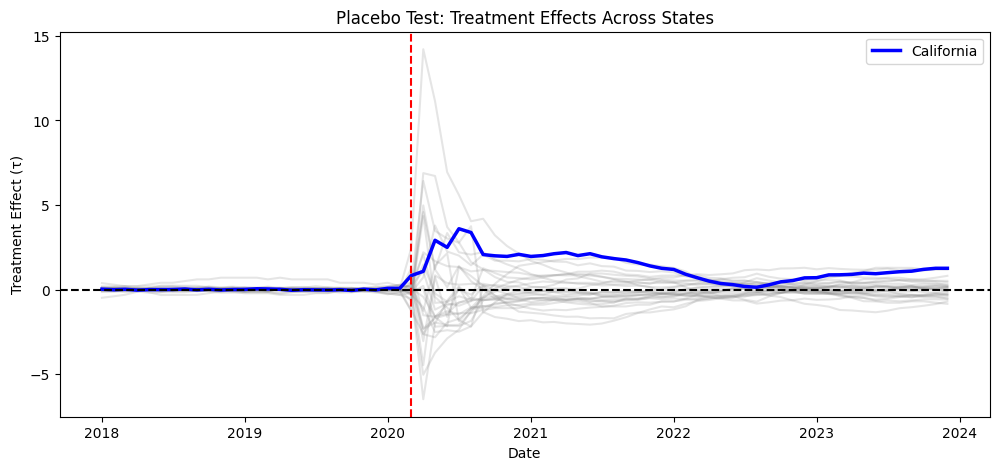

In [25]:
"""
Cell 21: Plot placebo treatment effects for all states,
highlighting California.
"""

plt.figure(figsize=(12, 5))

# Plot placebo effects (thin lines)
for state, tau_vals in tau_series_map.items():
    if state == "CA":
        continue
    plt.plot(y.index, tau_vals, color="gray", alpha=0.2)

# Plot California effect (thick line)
plt.plot(
    y.index,
    results["treatment_effect_tau"],
    color="blue",
    linewidth=2.5,
    label="California"
)

plt.axhline(0, linestyle="--", color="black")
plt.axvline(INTERVENTION_DATE, linestyle="--", color="red")

plt.title("Placebo Test: Treatment Effects Across States")
plt.xlabel("Date")
plt.ylabel("Treatment Effect (τ)")
plt.legend()
plt.show()


In [26]:
"""
Cell 22: Save outputs for reporting and reproducibility.

We save:
- Time-series results (observed, synthetic, tau)
- Summary statistics
- Placebo RMSE ratios
"""

# Save main results
results.to_csv(
    "../outputs/scm_unemployment_results_timeseries.csv",
    index=False
)

# Save summary statistics
summary_df = pd.DataFrame([{
    "pre_policy_rmse": pre_rmse,
    "average_post_policy_tau": avg_post_tau,
    "cumulative_post_policy_tau": cum_post_tau,
    "california_rmse_ratio": ca_ratio,
    "empirical_p_value": empirical_p_value,
    "california_rank": int(rank)
}])

summary_df.to_csv(
    "../outputs/scm_unemployment_summary.csv",
    index=False
)

# Save placebo results
placebo_df.to_csv(
    "../outputs/scm_unemployment_placebo_results.csv",
    index=False
)

print("All outputs saved successfully in the outputs/ folder.")


All outputs saved successfully in the outputs/ folder.
